# Predictive Analysis of Stress and Mental Health Factors


## Introduction

Mental health and stress are influenced by many different factors, including sleep quality, lifestyle habits and everyday routines. Poor sleep, increased stress levels and mental health difficulties are often connected and may affect both physical and emotional wellbeing.

This project analyzes stress and mental health-related data using two independent datasets. The goal is to examine possible relationships between sleep quality, anxiety, depression and other lifestyle-related factors.

The analysis will focus on identifying patterns, relationships and possible connections between stress levels, sleep quality and mental health-related factors.

## Datasets

1. `Sleep_health_and_lifestyle_dataset.csv`

2. `survey.csv`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Data Exploration

In [18]:
sleep_data = pd.read_csv("C:/Users/35988/Downloads/data/Sleep_health_and_lifestyle_dataset.csv")
mental_health_data = pd.read_csv("C:/Users/35988/Downloads/data/survey.csv")

In [19]:
sleep_data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [20]:
sleep_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [23]:
sleep_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Person ID,374.0,187.500000,108.108742,1.0,94.25,187.5,280.75,374.0
Age,374.0,42.184492,8.673133,27.0,35.25,43.0,50.00,59.0
Sleep Duration,374.0,7.132086,0.795657,5.8,6.40,7.2,7.80,8.5
Quality of Sleep,374.0,7.312834,1.196956,4.0,6.00,7.0,8.00,9.0
Physical Activity Level,374.0,59.171123,20.830804,30.0,45.00,60.0,75.00,90.0
Stress Level,374.0,5.385027,1.774526,3.0,4.00,5.0,7.00,8.0
Heart Rate,374.0,70.165775,4.135676,65.0,68.00,70.0,72.00,86.0
Daily Steps,374.0,6816.844920,1617.915679,3000.0,5600.00,7000.0,8000.00,10000.0


The initial exploration of the dataset provides a general overview of the available information related to sleep habits, stress levels and lifestyle-related factors. The dataset includes data related to sleep duration, quality of sleep, physical activity level, stress level and occupation.

The dataset appears relatively clean and well-structured, although some missing values are present in the `Sleep Disorder` column.

In [21]:
mental_health_data

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN


In [22]:
mental_health_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

The dataset contains workplace mental health survey responses related to treatment, work-related stress factors and mental health support. Most of the columns contain text-based information associated with workplace environment, mental health awareness and access to support resources.

The initial exploration also reveals the presence of missing values across several columns, as well as some unusual values in the `Age` column.

To ensure more reliable analysis results, both datasets are checked for missing and incomplete values before further analysis.

In [27]:
sleep_data.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [28]:
mental_health_data.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

The results show that the sleep dataset contains missing values mainly in the `Sleep Disorder` column, while the mental health dataset contains missing values across multiple columns.

## Data Cleaning

The datasets are checked for duplicated records.

In [29]:
sleep_data.duplicated().sum()

np.int64(0)

In [30]:
mental_health_data.duplicated().sum()

np.int64(0)

The results show that no duplicated records are present in either dataset.

The `Age` column in the mental health dataset is also examined because some unrealistic values were identified during the initial exploration.

In [35]:
mental_health_data["Age"].describe()

count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64

In [36]:
mental_health_data[
    (mental_health_data["Age"] < 0) |
    (mental_health_data["Age"] > 100)
]

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
143,2014-08-27 12:39:14,-29,Male,United States,MN,No,No,No,NaN,More than 1000,...,Don't know,No,No,Some of them,Yes,No,No,Don't know,No,NaN
364,2014-08-27 15:05:21,329,Male,United States,OH,No,No,Yes,Often,6-25,...,Don't know,Maybe,No,Some of them,No,No,No,No,No,NaN
390,2014-08-27 15:24:47,99999999999,All,Zimbabwe,NaN,Yes,Yes,Yes,Often,1-5,...,Very difficult,Yes,Yes,No,No,Yes,No,No,Yes,NaN
715,2014-08-28 10:07:53,-1726,male,United Kingdom,NaN,No,No,Yes,Sometimes,26-100,...,Somewhat difficult,Yes,No,No,No,No,Maybe,Don't know,No,NaN
1127,2014-08-30 20:55:11,-1,p,United States,AL,Yes,Yes,Yes,Often,1-5,...,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,password: testered


The inspection confirms the presence of unrealistic age values, including negative numbers and extremely large values, which will be filtered from the dataset.

In [37]:
mental_health_data = mental_health_data[
    (mental_health_data["Age"] >= 0) &
    (mental_health_data["Age"] <= 100)
]

In [38]:
mental_health_data["Age"].describe()

count    1254.000000
mean       32.019139
std         7.375005
min         5.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64

After filtering the unrealistic values, the `Age` column contains more consistent and reasonable data.

The `Gender` column is also checked for inconsistent text values.

In [39]:
mental_health_data["Gender"].value_counts()

Gender
Male                                              613
male                                              205
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Female (trans)                                      2
Female                                              2
Cis Male                                            2
Man                                                 2
msle                                                1
male leaning androgynous                            1
Cis Man                                             1
Trans woman          

The inspection of the `Gender` column shows multiple variations of similar values, including different spellings, abbreviations and text formatting. These entries will be grouped into three main categories in order to improve consistency within the dataset.

In [41]:
mental_health_data = mental_health_data.copy()

In [42]:
mental_health_data["Gender"] = mental_health_data["Gender"].str.lower()

In [43]:
mental_health_data["Gender"] = mental_health_data["Gender"].replace({
    "male": "Male",
    "m": "Male",
    "man": "Male",
    "cis male": "Male",
    "cis man": "Male",
    "male-ish": "Male",
    "maile": "Male",
    "malr": "Male",
    "mail": "Male",
    "make": "Male",

    "female": "Female",
    "f": "Female",
    "woman": "Female",
    "cis female": "Female",
    "cis-female/femme": "Female",
    "female (cis)": "Female",
    "femake": "Female",
    "femail": "Female"
})

In [44]:
mental_health_data["Gender"] = mental_health_data["Gender"].apply(
    lambda x: x if x in ["Male", "Female"] else "Other"
)

In [45]:
mental_health_data["Gender"].value_counts()

Gender
Male      982
Female    245
Other      27
Name: count, dtype: int64

After standardizing the values in the `Gender` column, the entries were grouped into three main categories: `Male`, `Female` and `Other`.

## Exploratory Data Analysis

Possible relationships between stress, sleep quality and mental health-related factors are explored through visualizations and data analysis.

The relationship between stress levels and sleep quality is examined in order to better understand how these factors may be connected.

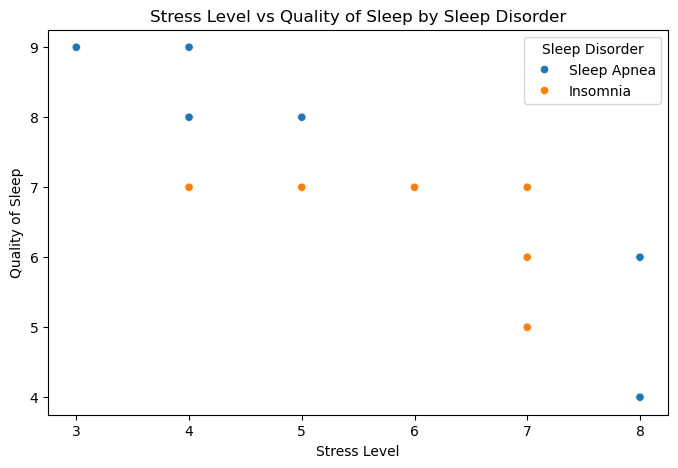

In [55]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=sleep_data,
    x="Stress Level",
    y="Quality of Sleep",
    hue="Sleep Disorder"
)

plt.title("Stress Level vs Quality of Sleep by Sleep Disorder")
plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")

plt.legend(title="Sleep Disorder")
plt.show()

The visualization suggests that higher stress levels are generally associated with lower sleep quality. Cases of insomnia appear more frequently at higher stress levels, while higher sleep quality is more visible at lower stress levels.

The relationship between sleep duration and stress level is also explored to examine whether shorter sleep duration is associated with increased stress.

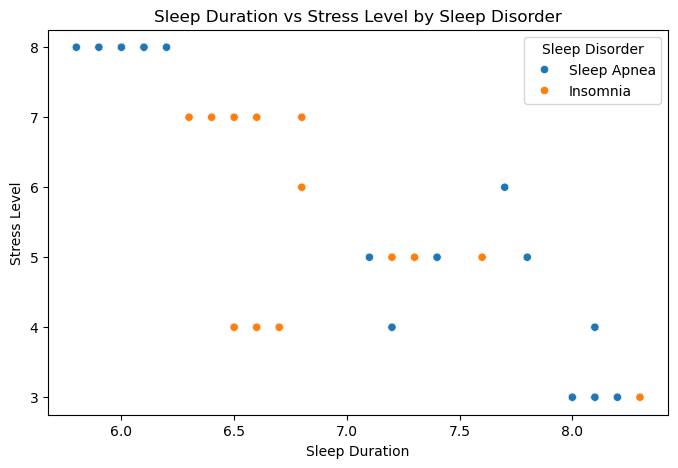

In [57]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=sleep_data,
    x="Sleep Duration",
    y="Stress Level",
    hue="Sleep Disorder"
)

plt.title("Sleep Duration vs Stress Level by Sleep Disorder")
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")

plt.legend(title="Sleep Disorder")
plt.show()

The visualization indicates that people who sleep fewer hours generally tend to experience higher stress levels. As sleep duration increases, stress levels appear to become lower for many individuals in the dataset.
The graph also suggests that insomnia cases are more commonly observed among individuals with shorter sleep duration and higher stress levels. On the other hand, longer sleep duration is more often associated with lower stress levels and healthier sleep patterns.

The relationship between physical activity level and stress level is explored to examine whether increased physical activity is associated with lower stress levels.

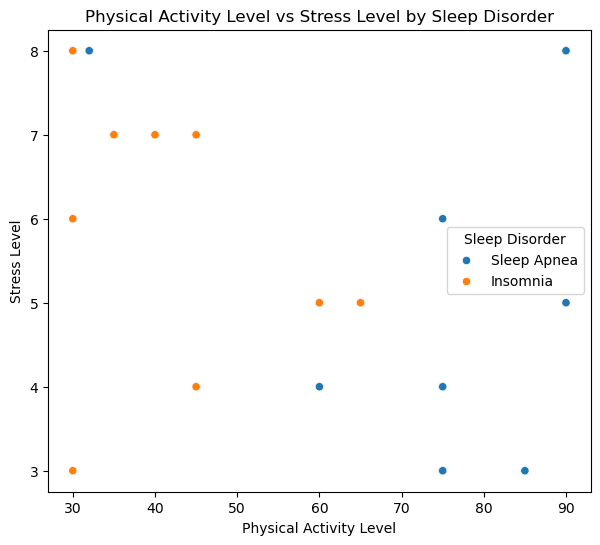

In [66]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=sleep_data,
    x="Physical Activity Level",
    y="Stress Level",
    hue="Sleep Disorder"
)

plt.title("Physical Activity Level vs Stress Level by Sleep Disorder")
plt.xlabel("Physical Activity Level")
plt.ylabel("Stress Level")

plt.legend(title="Sleep Disorder")
plt.show()

The visualization suggests that lower physical activity levels are more commonly associated with higher stress levels. In contrast, individuals with higher physical activity levels tend to report lower stress levels more frequently.
The graph also shows that insomnia cases appear more concentrated among individuals with lower physical activity and moderate to high stress levels.

The following visualization shows how the sleep disorder categories are represented in the dataset.

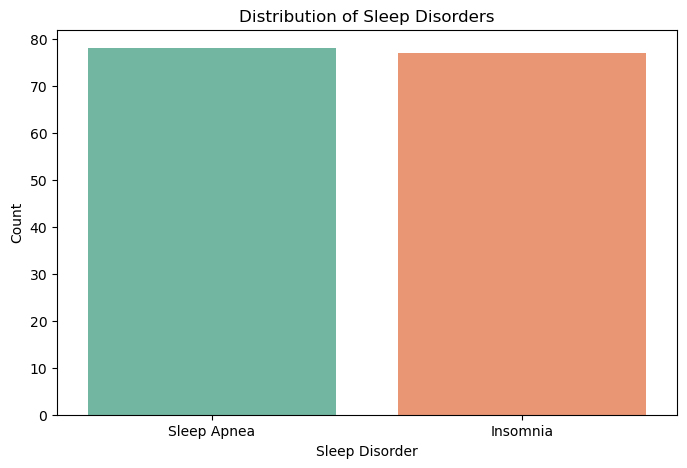

In [70]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=sleep_data,
    x="Sleep Disorder",
    hue="Sleep Disorder",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")

plt.show()

The following heatmap helps visualize how the main values in the sleep dataset are connected to one another.

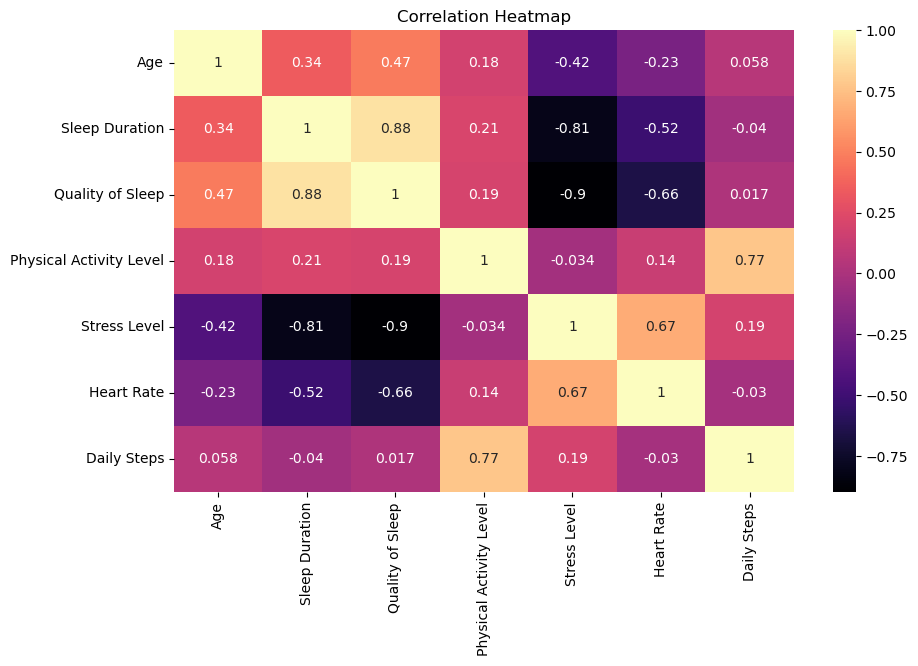

In [77]:
sleep_corr = sleep_data.drop(columns=["Person ID"])

plt.figure(figsize=(10, 6))

sns.heatmap(
    sleep_corr.corr(numeric_only=True),
    annot=True,
    cmap="magma"
)

plt.title("Correlation Heatmap")
plt.show()

The heatmap helps show how the main values in the dataset are related to each other. One of the strongest relationships can be seen between sleep duration and quality of sleep, where longer sleep duration is generally connected with better sleep quality.

A strong negative relationship can also be observed between stress level and both sleep duration and quality of sleep. This means that higher stress levels are often linked to shorter sleep duration and lower sleep quality.

The heatmap also shows a positive relationship between physical activity level and daily steps, suggesting that people with higher physical activity levels usually record more daily steps as well.

## Statistical Analysis

The following statistical methods are used to further explore the relationships between stress, sleep quality, physical activity, and sleep disorders. The goal is to better understand whether some of the differences between the groups are meaningful within the dataset.

### Stress Level Analysis

This analysis explores whether stress levels differ between individuals with insomnia and sleep apnea.

In [84]:
insomnia_stress = sleep_data[
    sleep_data["Sleep Disorder"] == "Insomnia"
]["Stress Level"]

sleep_apnea_stress = sleep_data[
    sleep_data["Sleep Disorder"] == "Sleep Apnea"
]["Stress Level"]

In [85]:
from scipy.stats import ttest_ind

In [86]:
t_statistic, p_value = ttest_ind(
    insomnia_stress,
    sleep_apnea_stress
)

In [87]:
print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 0.6493577003853104
P-value: 0.5170808294425422


The results of the t-test show that there is no statistically significant difference in stress levels between individuals with insomnia and sleep apnea, since the p-value is greater than 0.05.


### Physical Activity and Stress

This analysis examines whether physical activity levels are related to stress levels in the dataset.


In [88]:
physical_activity = sleep_data["Physical Activity Level"]

stress_level = sleep_data["Stress Level"]

In [89]:
from scipy.stats import pearsonr

In [90]:
correlation, p_value = pearsonr(
    physical_activity,
    stress_level
)

In [91]:
print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: -0.03413446351674277
P-value: 0.5104666785066971


The results show a very weak relationship between physical activity and stress levels. Since the p-value is greater than 0.05, the relationship is not considered statistically significant in this dataset.

### Sleep Duration and Sleep Quality

This analysis explores the relationship between sleep duration and sleep quality.

In [96]:
sleep_duration = sleep_data["Sleep Duration"]

sleep_quality = sleep_data["Quality of Sleep"]

In [97]:
correlation, p_value = pearsonr(
    sleep_duration,
    sleep_quality
)

In [98]:
print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.8832130004106182
P-value: 2.170991770864778e-124


The results show a strong positive relationship between sleep duration and sleep quality. This means that individuals who sleep for longer periods generally tend to report better sleep quality. 

The correlation value of 0.88 indicates a very strong connection between the two factors, while the extremely small p-value suggests that the relationship is statistically significant and unlikely to be caused by random variation in the dataset.


## Summary of Statistical Results

The statistical analysis showed mixed results across the examined relationships. The t-test comparing stress levels between individuals with insomnia and sleep apnea produced a p-value of 0.517, indicating that no statistically significant difference was found between the two groups.

The correlation test between physical activity and stress level showed a very weak negative relationship (`correlation = -0.03`) with a p-value greater than 0.05, suggesting that physical activity was not significantly related to stress levels in this dataset.

The strongest result was observed between sleep duration and sleep quality. The correlation value of `0.88` and the extremely small p-value indicated a strong and statistically significant positive relationship between the two factors.

# Conclusion

This project explored the relationships between sleep habits, stress levels, physical activity, and sleep disorders using data analysis and visualizations.

The exploratory data analysis showed that higher stress levels are generally connected with lower sleep quality and shorter sleep duration. Individuals with longer sleep duration were more likely to report better sleep quality, while higher stress levels were often associated with poorer sleep patterns.

The statistical analysis supported some of these observations. A strong positive relationship was found between sleep duration and sleep quality, suggesting that longer sleep is closely connected with better overall sleep quality. On the other hand, no statistically significant difference was found in stress levels between individuals with insomnia and sleep apnea in this dataset.

Overall, the analysis suggests that sleep duration and stress levels may play an important role in sleep quality and general sleep health.